In [1]:
!pip install pandas pyarrow statsforecast utilsforecast mlforecast lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 467.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 389.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 302.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 

In [5]:
import pandas as pd

df = pd.read_parquet("Data")

print(df.head())

print(df.shape)

     unique_id         ds holiday_flag target_day target_month  target_year  \
1430   hotel_0 2022-01-01           no        Sat          Jan         2022   
1431   hotel_0 2022-01-02           no        Sun          Jan         2022   
1432   hotel_0 2022-01-03           no        Mon          Jan         2022   
1433   hotel_0 2022-01-04           no        Tue          Jan         2022   
1434   hotel_0 2022-01-05           no        Wed          Jan         2022   

     location_type              hotel_type         y     otb_1  ...    otb_51  \
1430   NonSuburban  Resorts & Destinations  0.975309  0.679012  ...  0.197531   
1431   NonSuburban  Resorts & Destinations  0.493827  0.308642  ...  0.074074   
1432   NonSuburban  Resorts & Destinations  0.456790  0.358025  ...  0.024691   
1433   NonSuburban  Resorts & Destinations  0.592593  0.419753  ...  0.074074   
1434   NonSuburban  Resorts & Destinations  0.530864  0.407407  ...  0.074074   

        otb_52    otb_53    otb_54    

In [7]:
print(df.columns)

Index(['unique_id', 'ds', 'holiday_flag', 'target_day', 'target_month',
       'target_year', 'location_type', 'hotel_type', 'y', 'otb_1', 'otb_2',
       'otb_3', 'otb_4', 'otb_5', 'otb_6', 'otb_7', 'otb_8', 'otb_9', 'otb_10',
       'otb_11', 'otb_12', 'otb_13', 'otb_14', 'otb_15', 'otb_16', 'otb_17',
       'otb_18', 'otb_19', 'otb_20', 'otb_21', 'otb_22', 'otb_23', 'otb_24',
       'otb_25', 'otb_26', 'otb_27', 'otb_28', 'otb_29', 'otb_30', 'otb_31',
       'otb_32', 'otb_33', 'otb_34', 'otb_35', 'otb_36', 'otb_37', 'otb_38',
       'otb_39', 'otb_40', 'otb_41', 'otb_42', 'otb_43', 'otb_44', 'otb_45',
       'otb_46', 'otb_47', 'otb_48', 'otb_49', 'otb_50', 'otb_51', 'otb_52',
       'otb_53', 'otb_54', 'otb_55', 'otb_56', 'otb_57', 'otb_58', 'otb_59',
       'otb_60'],
      dtype='object')


In [9]:
print(df.isnull().sum())

unique_id       0
ds              0
holiday_flag    0
target_day      0
target_month    0
               ..
otb_56          0
otb_57          0
otb_58          0
otb_59          0
otb_60          0
Length: 69, dtype: int64


In [11]:
import pandas as pd

# convert date column
df['ds'] = pd.to_datetime(df['ds'])

# sort values
df = df.sort_values(['unique_id', 'ds'])

# reset index
df = df.reset_index(drop=True)

# check data types
print(df.dtypes.head(10))

unique_id                object
ds               datetime64[us]
holiday_flag             object
target_day               object
target_month             object
target_year               int32
location_type            object
hotel_type               object
y                       float64
otb_1                   float64
dtype: object


In [13]:
series_counts = df.groupby('unique_id').size()

print(series_counts.head())

print("Number of hotels:", df['unique_id'].nunique())

unique_id
hotel_0      546
hotel_105    546
hotel_112    546
hotel_126    546
hotel_133    546
dtype: int64
Number of hotels: 19


In [15]:
sample_hotel = df[df['unique_id'] == 'hotel_0']

print(sample_hotel.head())

  unique_id         ds holiday_flag target_day target_month  target_year  \
0   hotel_0 2022-01-01           no        Sat          Jan         2022   
1   hotel_0 2022-01-02           no        Sun          Jan         2022   
2   hotel_0 2022-01-03           no        Mon          Jan         2022   
3   hotel_0 2022-01-04           no        Tue          Jan         2022   
4   hotel_0 2022-01-05           no        Wed          Jan         2022   

  location_type              hotel_type         y     otb_1  ...    otb_51  \
0   NonSuburban  Resorts & Destinations  0.975309  0.679012  ...  0.197531   
1   NonSuburban  Resorts & Destinations  0.493827  0.308642  ...  0.074074   
2   NonSuburban  Resorts & Destinations  0.456790  0.358025  ...  0.024691   
3   NonSuburban  Resorts & Destinations  0.592593  0.419753  ...  0.074074   
4   NonSuburban  Resorts & Destinations  0.530864  0.407407  ...  0.074074   

     otb_52    otb_53    otb_54    otb_55    otb_56    otb_57    otb_58  \

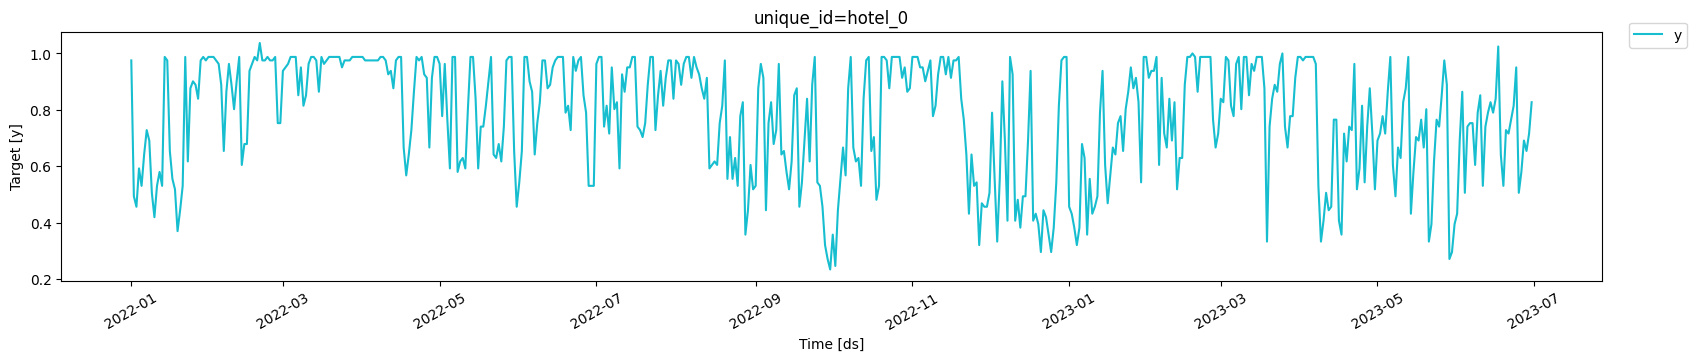

In [17]:
from utilsforecast.plotting import plot_series

plot_series(
    sample_hotel,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

In [19]:
# forecast horizon
h = 28

# split train and test
train = df.groupby('unique_id').head(len(df[df['unique_id']=='hotel_0']) - h)

test = df.groupby('unique_id').tail(h)

print(train.shape)
print(test.shape)

(9668, 69)
(532, 69)


In [25]:
# keep only required columns
train_sf = train[['unique_id', 'ds', 'y']]

test_sf = test[['unique_id', 'ds', 'y']]

print(train_sf.head())

  unique_id         ds         y
0   hotel_0 2022-01-01  0.975309
1   hotel_0 2022-01-02  0.493827
2   hotel_0 2022-01-03  0.456790
3   hotel_0 2022-01-04  0.592593
4   hotel_0 2022-01-05  0.530864


In [27]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive

# baseline models
baseline_models = [
    Naive(),
    SeasonalNaive(season_length=7)
]

# create model object
sf_baseline = StatsForecast(
    models=baseline_models,
    freq='D',
    n_jobs=-1
)

In [29]:
baseline_forecasts = sf_baseline.forecast(
    df=train_sf,
    h=h
)

print(baseline_forecasts.head())

  unique_id         ds     Naive  SeasonalNaive
0   hotel_0 2023-06-03  0.691358       0.975309
1   hotel_0 2023-06-04  0.691358       0.888889
2   hotel_0 2023-06-05  0.691358       0.271605
3   hotel_0 2023-06-06  0.691358       0.296296
4   hotel_0 2023-06-07  0.691358       0.395062


In [31]:
baseline_eval = test_sf.merge(
    baseline_forecasts,
    on=["unique_id", "ds"],
    how="left"
)

print(baseline_eval.head())
print(baseline_eval.shape)

  unique_id         ds         y     Naive  SeasonalNaive
0   hotel_0 2023-06-03  0.864198  0.691358       0.975309
1   hotel_0 2023-06-04  0.506173  0.691358       0.888889
2   hotel_0 2023-06-05  0.740741  0.691358       0.271605
3   hotel_0 2023-06-06  0.753086  0.691358       0.296296
4   hotel_0 2023-06-07  0.753086  0.691358       0.395062
(532, 5)


In [43]:
import pandas as pd
import numpy as np

def calculate_metrics(df, model_name):

    error = df["y"] - df[model_name]

    me = error.mean()

    mae = error.abs().mean()

    rmse = np.sqrt((error ** 2).mean())

    # avoid division by zero
    nonzero = df["y"] != 0

    mape = (
        error[nonzero].abs() / df.loc[nonzero, "y"]
    ).mean() * 100

    return pd.Series({
        "model": model_name,
        "ME": me,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

In [45]:
from statsforecast.models import AutoETS, AutoARIMA

stats_models = [
    AutoETS(season_length=7),
    AutoARIMA(season_length=7)
]

sf_stats = StatsForecast(
    models=stats_models,
    freq='D',
    n_jobs=-1
)

stats_forecasts = sf_stats.forecast(
    df=train_sf,
    h=h
)

print(stats_forecasts.head())

  unique_id         ds   AutoETS  AutoARIMA
0   hotel_0 2023-06-03  0.665170   0.768889
1   hotel_0 2023-06-04  0.446198   0.652806
2   hotel_0 2023-06-05  0.463018   0.468714
3   hotel_0 2023-06-06  0.497479   0.523568
4   hotel_0 2023-06-07  0.494638   0.586709


In [47]:
# merge forecasts
stats_eval = test_sf.merge(
    stats_forecasts,
    on=["unique_id", "ds"],
    how="left"
)

print(stats_eval.head())

  unique_id         ds         y   AutoETS  AutoARIMA
0   hotel_0 2023-06-03  0.864198  0.665170   0.768889
1   hotel_0 2023-06-04  0.506173  0.446198   0.652806
2   hotel_0 2023-06-05  0.740741  0.463018   0.468714
3   hotel_0 2023-06-06  0.753086  0.497479   0.523568
4   hotel_0 2023-06-07  0.753086  0.494638   0.586709


In [49]:
stats_metrics = pd.DataFrame([
    calculate_metrics(stats_eval, "AutoETS"),
    calculate_metrics(stats_eval, "AutoARIMA")
])

print(stats_metrics)

       model        ME       MAE      RMSE       MAPE
0    AutoETS  0.068280  0.109667  0.151906  18.851218
1  AutoARIMA  0.037007  0.090652  0.126735  17.198575


In [51]:
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences

from lightgbm import LGBMRegressor

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse

In [53]:
# prepare data for MLForecast
train_ml = train.copy()
test_ml = test.copy()

# convert categorical variables to numeric/dummy variables
train_ml = pd.get_dummies(
    train_ml,
    columns=["holiday_flag", "target_day", "target_month", "location_type", "hotel_type"],
    drop_first=True
)

test_ml = pd.get_dummies(
    test_ml,
    columns=["holiday_flag", "target_day", "target_month", "location_type", "hotel_type"],
    drop_first=True
)

# make sure train and test have the same columns
train_ml, test_ml = train_ml.align(test_ml, join="left", axis=1, fill_value=0)

print(train_ml.shape)
print(test_ml.shape)
print(train_ml.head())

(9668, 85)
(532, 85)
  unique_id         ds  target_year         y     otb_1     otb_2     otb_3  \
0   hotel_0 2022-01-01         2022  0.975309  0.679012  0.604938  0.555556   
1   hotel_0 2022-01-02         2022  0.493827  0.308642  0.320988  0.296296   
2   hotel_0 2022-01-03         2022  0.456790  0.358025  0.308642  0.296296   
3   hotel_0 2022-01-04         2022  0.592593  0.419753  0.407407  0.358025   
4   hotel_0 2022-01-05         2022  0.530864  0.407407  0.395062  0.419753   

      otb_4     otb_5     otb_6  ...  target_month_Jun  target_month_Mar  \
0  0.518519  0.530864  0.530864  ...             False             False   
1  0.296296  0.259259  0.234568  ...             False             False   
2  0.296296  0.222222  0.222222  ...             False             False   
3  0.358025  0.358025  0.308642  ...             False             False   
4  0.382716  0.382716  0.370370  ...             False             False   

   target_month_May  target_month_Nov  target_m

In [57]:
# fill missing dates for each hotel
train_ml = (
    train_ml
    .groupby("unique_id")
    .apply(
        lambda x: x.set_index("ds")
        .asfreq("D")
        .reset_index()
    )
    .reset_index(drop=True)
)

# fill missing values
train_ml["unique_id"] = train_ml["unique_id"].ffill()

# numeric columns
numeric_cols = train_ml.select_dtypes(include=["number"]).columns

train_ml[numeric_cols] = train_ml[numeric_cols].fillna(0)

# categorical/object columns
object_cols = train_ml.select_dtypes(include=["object", "bool"]).columns

train_ml[object_cols] = train_ml[object_cols].ffill()

In [63]:
from mlforecast import MLForecast
from lightgbm import LGBMRegressor

# -----------------------------
# Prepare data for LightGBM
# Use only required columns first
# -----------------------------
train_lgbm = train_sf.copy()

# Fill missing daily dates for each hotel
train_lgbm = (
    train_lgbm
    .groupby("unique_id")
    .apply(
        lambda x: x.set_index("ds")
        .asfreq("D")
        .reset_index()
    )
    .reset_index(drop=True)
)

# Fill unique_id and missing y values
train_lgbm["unique_id"] = train_lgbm["unique_id"].ffill()
train_lgbm["y"] = train_lgbm["y"].fillna(0)

# -----------------------------
# Build MLForecast model
# -----------------------------
mlf = MLForecast(
    models={
        "LightGBM": LGBMRegressor(
            n_estimators=100,
            learning_rate=0.05,
            random_state=123
        )
    },
    freq="D",
    lags=[1, 7, 14, 28],
    date_features=["dayofweek", "month"]
)

# -----------------------------
# Fit model
# -----------------------------
mlf.fit(
    train_lgbm,
    id_col="unique_id",
    time_col="ds",
    target_col="y"
)

# -----------------------------
# Forecast next 28 days
# -----------------------------
lgbm_forecasts = mlf.predict(h=h)

print(lgbm_forecasts.head())
print(lgbm_forecasts.shape)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 9152, number of used features: 6
[LightGBM] [Info] Start training from score 0.671606
  unique_id         ds  LightGBM
0   hotel_0 2023-06-03  0.822415
1   hotel_0 2023-06-04  0.601920
2   hotel_0 2023-06-05  0.614698
3   hotel_0 2023-06-06  0.605192
4   hotel_0 2023-06-07  0.601004
(532, 3)


In [65]:
lgbm_eval = test_sf.merge(
    lgbm_forecasts,
    on=["unique_id", "ds"],
    how="left"
)

print(lgbm_eval.head())
print(lgbm_eval.shape)

  unique_id         ds         y  LightGBM
0   hotel_0 2023-06-03  0.864198  0.822415
1   hotel_0 2023-06-04  0.506173  0.601920
2   hotel_0 2023-06-05  0.740741  0.614698
3   hotel_0 2023-06-06  0.753086  0.605192
4   hotel_0 2023-06-07  0.753086  0.601004
(532, 4)


In [67]:
lgbm_metrics = pd.DataFrame([
    calculate_metrics(lgbm_eval, "LightGBM")
])

print(lgbm_metrics)

      model        ME       MAE      RMSE      MAPE
0  LightGBM  0.026699  0.093376  0.123362  20.23625


In [69]:
all_metrics = pd.concat([
    baseline_metrics,
    stats_metrics,
    lgbm_metrics
], ignore_index=True)

print(all_metrics)

           model        ME       MAE      RMSE       MAPE
0          Naive  0.013229  0.099858  0.146273  20.928368
1  SeasonalNaive  0.064161  0.143566  0.202739  24.547541
2        AutoETS  0.068280  0.109667  0.151906  18.851218
3      AutoARIMA  0.037007  0.090652  0.126735  17.198575
4       LightGBM  0.026699  0.093376  0.123362  20.236250


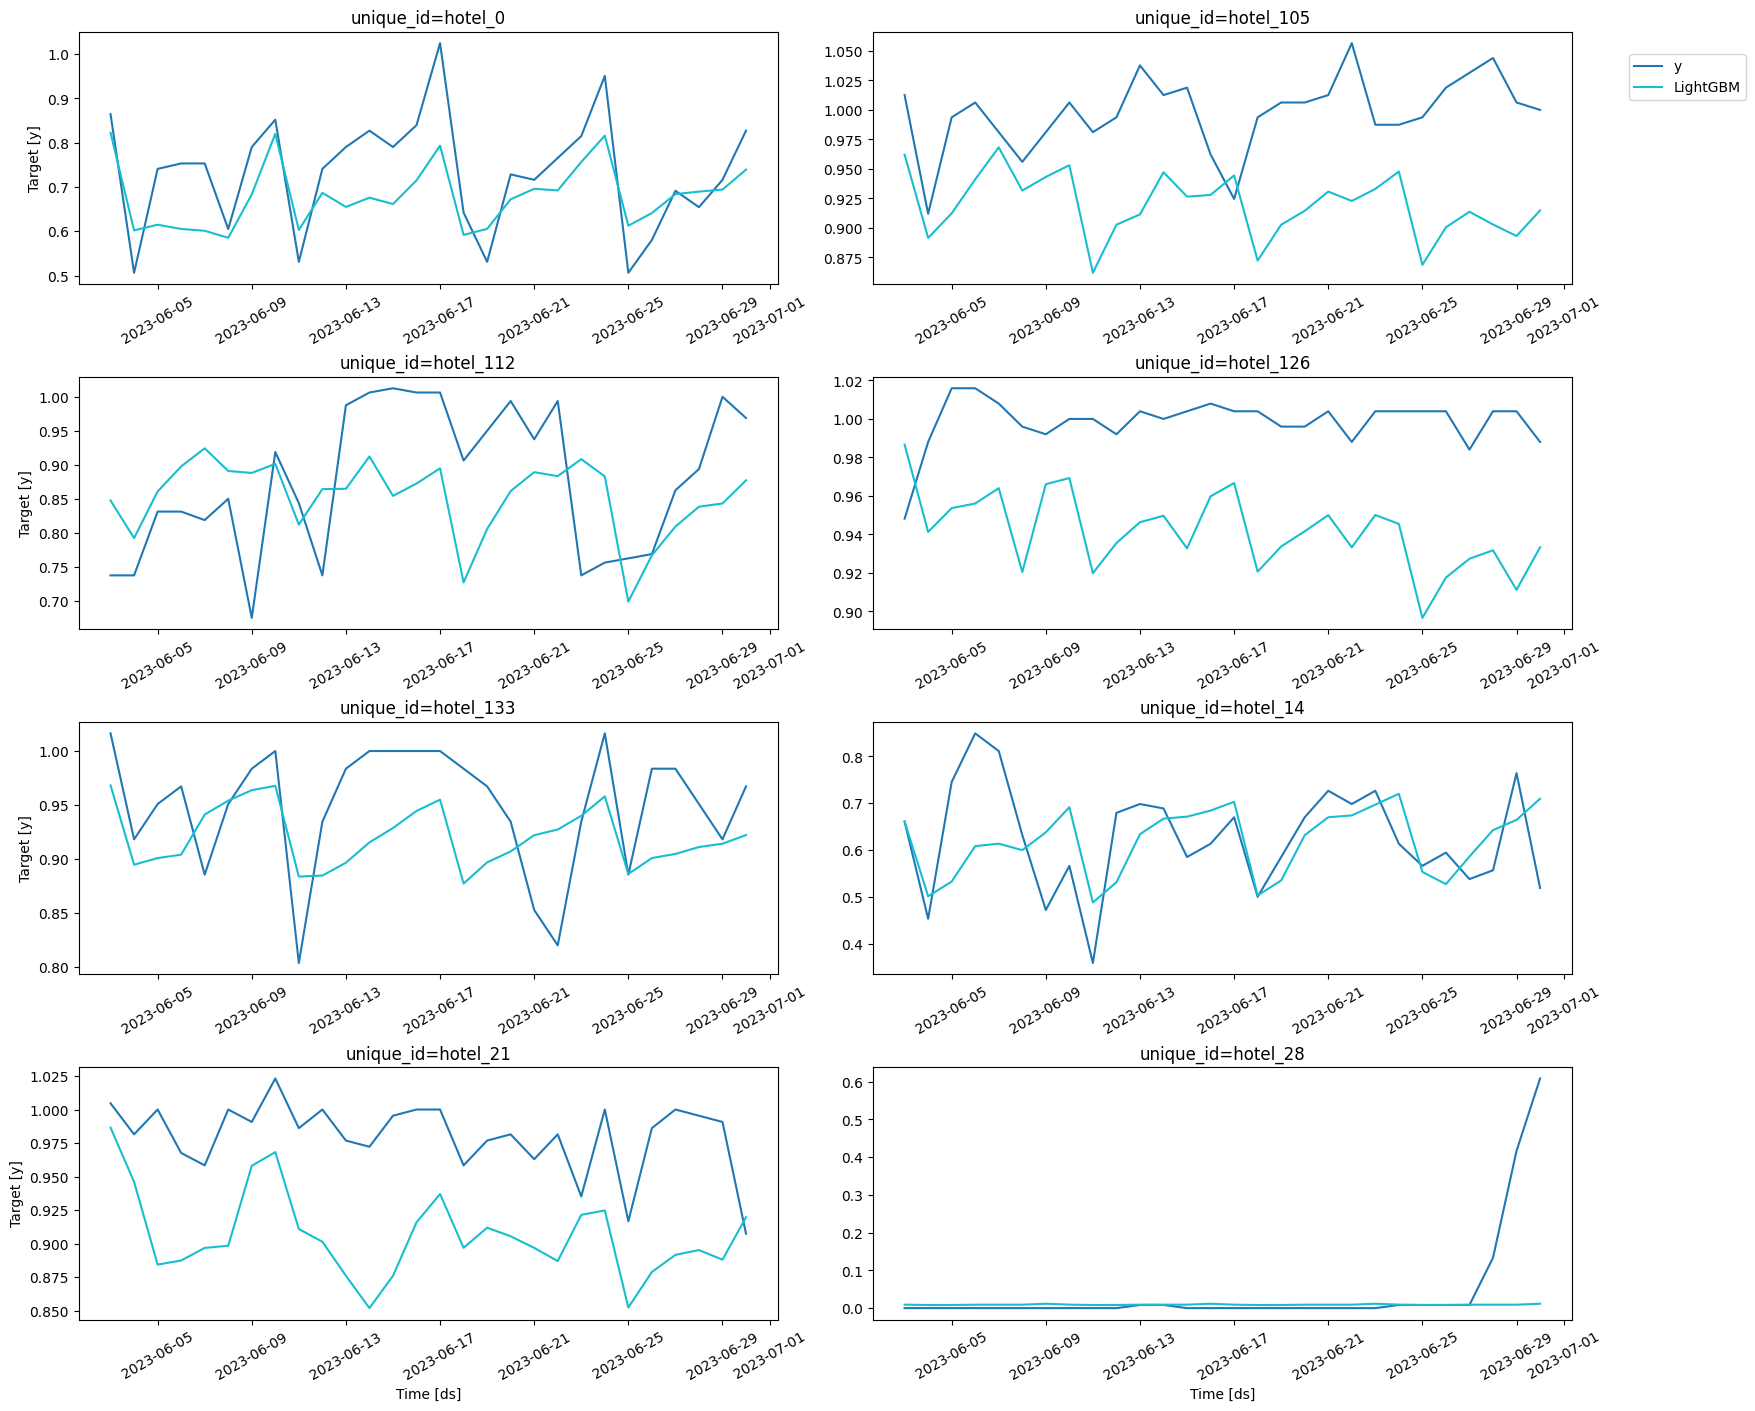

In [75]:
from utilsforecast.plotting import plot_series

plot_series(
    forecasts_df=lgbm_eval,
    ids=lgbm_eval["unique_id"].unique()[:8],
    plot_random=False,
    models=["LightGBM"],
    level=None
)

In [93]:
import os

os.makedirs("csv_results", exist_ok=True)
os.makedirs("csv_outputs", exist_ok=True)

In [95]:
all_metrics.to_csv(
    "csv_results/model_metrics_summary.csv",
    index=False
)

baseline_forecasts.to_csv(
    "csv_outputs/baseline_forecasts.csv",
    index=False
)

stats_forecasts.to_csv(
    "csv_outputs/stats_forecasts.csv",
    index=False
)

lgbm_forecasts.to_csv(
    "csv_outputs/lgbm_forecasts.csv",
    index=False
)

In [97]:
# sort by RMSE
rmse_ranking = all_metrics.sort_values("RMSE")

print(rmse_ranking)

           model        ME       MAE      RMSE       MAPE
4       LightGBM  0.026699  0.093376  0.123362  20.236250
3      AutoARIMA  0.037007  0.090652  0.126735  17.198575
0          Naive  0.013229  0.099858  0.146273  20.928368
2        AutoETS  0.068280  0.109667  0.151906  18.851218
1  SeasonalNaive  0.064161  0.143566  0.202739  24.547541


In [99]:
# sort by MAE
mae_ranking = all_metrics.sort_values("MAE")

print(mae_ranking)

           model        ME       MAE      RMSE       MAPE
3      AutoARIMA  0.037007  0.090652  0.126735  17.198575
4       LightGBM  0.026699  0.093376  0.123362  20.236250
0          Naive  0.013229  0.099858  0.146273  20.928368
2        AutoETS  0.068280  0.109667  0.151906  18.851218
1  SeasonalNaive  0.064161  0.143566  0.202739  24.547541


In [101]:
comparison_df = lgbm_eval.merge(
    baseline_eval[["unique_id", "ds", "Naive"]],
    on=["unique_id", "ds"]
)

comparison_df = comparison_df.merge(
    stats_eval[["unique_id", "ds", "AutoARIMA"]],
    on=["unique_id", "ds"]
)

print(comparison_df.head())

  unique_id         ds         y  LightGBM     Naive  AutoARIMA
0   hotel_0 2023-06-03  0.864198  0.822415  0.691358   0.768889
1   hotel_0 2023-06-04  0.506173  0.601920  0.691358   0.652806
2   hotel_0 2023-06-05  0.740741  0.614698  0.691358   0.468714
3   hotel_0 2023-06-06  0.753086  0.605192  0.691358   0.523568
4   hotel_0 2023-06-07  0.753086  0.601004  0.691358   0.586709


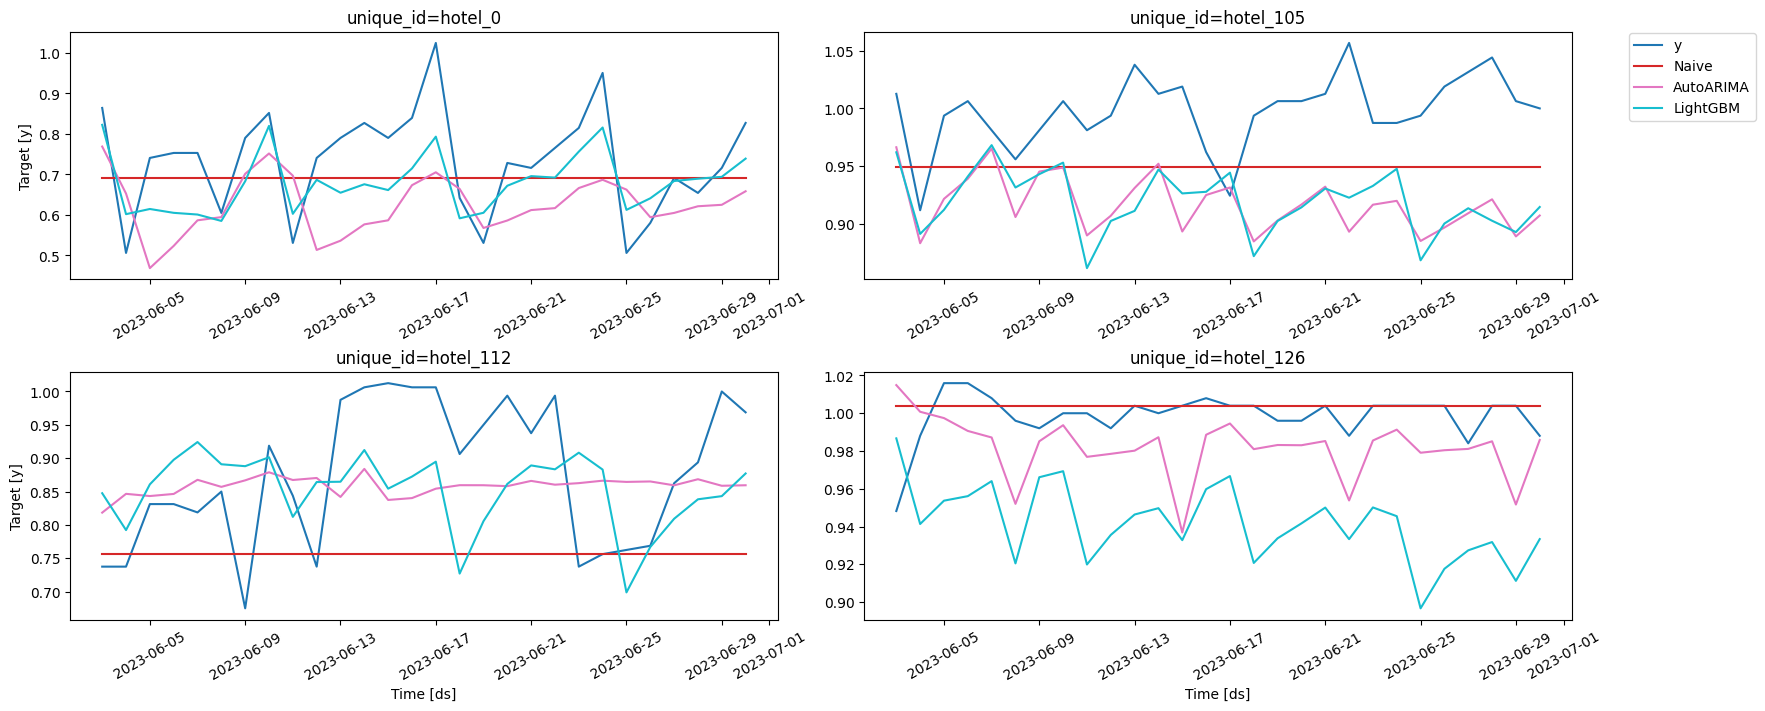

In [103]:
from utilsforecast.plotting import plot_series

plot_series(
    forecasts_df=comparison_df,
    ids=comparison_df["unique_id"].unique()[:4],
    plot_random=False,
    models=["Naive", "AutoARIMA", "LightGBM"],
    level=None
)

## Model Performance Summary

We compared five forecasting models for hotel demand forecasting: Naive, Seasonal Naive, AutoETS, AutoARIMA, and LightGBM.

Based on the evaluation results, AutoARIMA achieved the lowest MAE and MAPE, while LightGBM achieved the lowest RMSE. This means AutoARIMA had the smallest average absolute error, while LightGBM reduced larger errors more effectively.

The baseline models were useful benchmarks, but they were generally outperformed by AutoARIMA and LightGBM. Seasonal Naive performed worst in this testing period, suggesting that simple weekly repetition alone was not enough to capture hotel demand variation.

Overall, AutoARIMA and LightGBM were the strongest models in this project.

## Final Conclusion

This project followed a complete time-series forecasting workflow for hotel demand forecasting. The workflow included data preparation, exploratory visualization, train/test splitting, model fitting, forecast evaluation, and forecast visualization.

The models were evaluated using ME, MAE, RMSE, and MAPE. Because some actual values were zero, MAPE was calculated only for nonzero actual observations to avoid division-by-zero problems.

The final results show that AutoARIMA performed best by MAE and MAPE, while LightGBM performed best by RMSE. This suggests that statistical forecasting models can still perform very well for hotel demand, while machine learning models can help reduce larger forecast errors.

For future improvement, the model could incorporate more external variables such as local events, weather, pricing, and holidays.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b0c74f93-4dac-4207-b5eb-e38222b3ffd3' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>